# 6CS012 – Worksheet 6
## Image Classification with CNN and Transfer Learning

**Student Name:** Aakriti Basnet  
**Student ID:** 2418566

***Import libraries***



In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


***Dataset Path***


In [ ]:
import os
print(os.path.exists("/content/FruitinAmazon.zip"))

True


In [16]:
from google.colab import files
files.upload()

Saving FruitinAmazon.zip to FruitinAmazon (1).zip


{'FruitinAmazon (1).zip': b'PK\x03\x04\x14\x00\x08\x08\x08\x00\x00\x00!\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00,\x00b\x00FruitinAmazon/test/cupuacu/download (5).jpegUT\x05\x00\x01B\x1d\xa4_\n\x00 \x00\x00\x00\x00\x00\x01\x00\x18\x00\x00\xcd\xa1/\x8a\xb3\xd6\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00up1\x00\x01\x98n\xb6\x10FruitinAmazon/test/cupuacu/download (5).jpeg\x01\xca(5\xd7\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x13\x13\x12\x15\x13\x13\x14\x15\x15\x15\x17\x19\x1d\x1a\x18\x18\x18\x17\x1a\x1b\x1a\x1a\x1e\x18\x19\x1e\x17\x18\x18\x17\x17\x1d\x1d( \x18\x1a%\x1d\x1a\x18!1!%)+...\x18\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1b\x10\x10\x1b-%\x1f%------/-------------------------------------------\xff\xc0\x00\x11\x08\x00\xc2\x01\x03\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x02\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x05\x03\x06\x00\x01\x02\x07\x08\xff\xc4\x00=\x1

In [17]:
import zipfile

zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [18]:
import os
print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [19]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['train', 'test']


In [20]:
train_dir = "/content/dataset/train"
test_dir  = "/content/dataset/test"

In [21]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir  = "/content/dataset/FruitinAmazon/test"

In [22]:
print(os.listdir(train_dir))

['graviola', 'guarana', 'acai', 'pupunha', 'cupuacu', 'tucuma']


***Part A — Dataset Understanding and Visualization***

***Read dataset directory and class names***

In [23]:
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


***Check corrupted images***


In [24]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


***Check class distribution***

In [25]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


***Select one random image from each class***

In [26]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

***Plot random images***

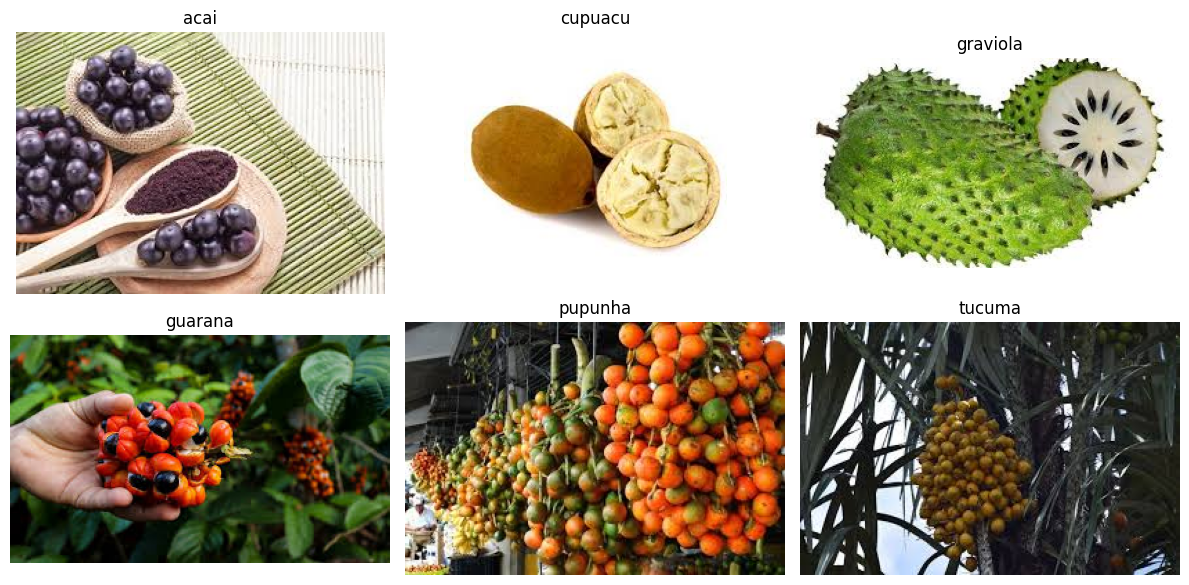

In [27]:
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

***Part B — Data Generation and Pre-processing***

***Create train and validation datasets***

In [28]:
image_size = (28, 28)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


***Create test dataset***

In [29]:
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    color_mode="grayscale"
)

Found 30 files belonging to 6 classes.


***Check dataset batch shape***

In [30]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 1)
Labels shape: (32,)


***Visualize training dataset***

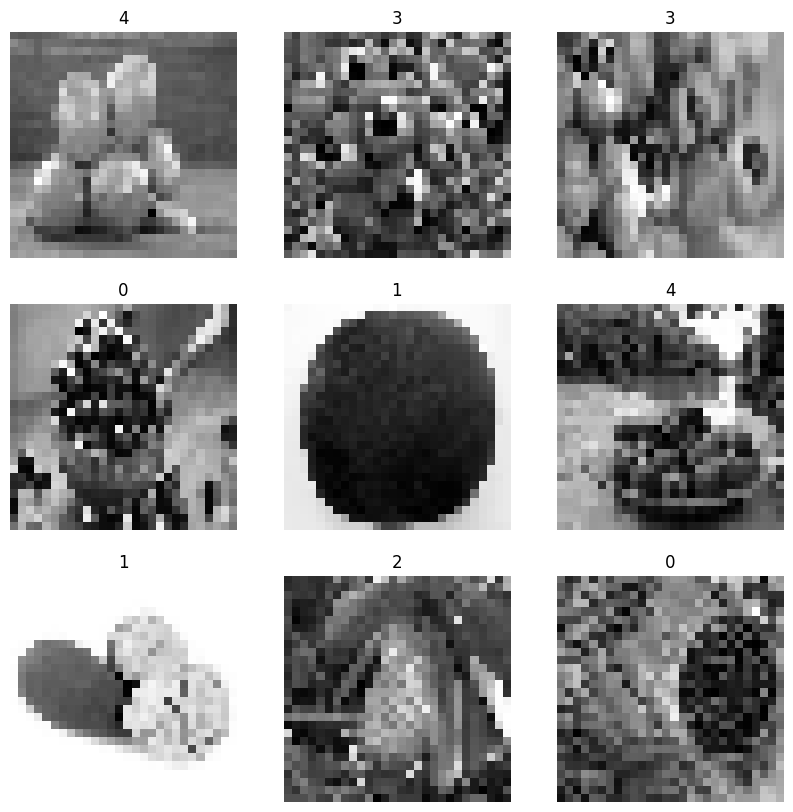

In [31]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8").squeeze(), cmap="gray")
        plt.title(int(labels[i]))
        plt.axis("off")

plt.show()

***Part C — Data Augmentation***

In [32]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

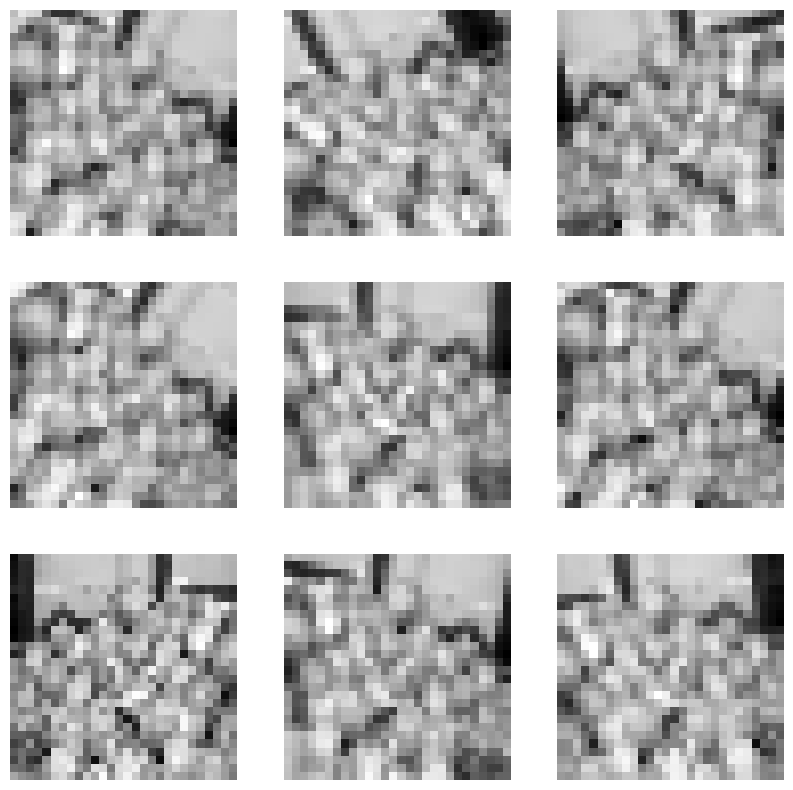

In [33]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8").squeeze(), cmap="gray")
        plt.axis("off")

plt.show()

***Part D — Improved CNN Model with BN and Dropout***

***improved CNN***

In [34]:
num_classes = len(class_names)

model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(28, 28, 1)),
    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             

 Total params: 698,054 (2.66 MB)

 Trainable params: 695,174 (2.65 MB)

 Non-trainable params: 2,880 (11.25 KB)

***Train the CNN model***

In [35]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.1806 - loss: 2.3185 - val_accuracy: 0.2222 - val_loss: 1.7887
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1667 - loss: 2.3791 - val_accuracy: 0.2222 - val_loss: 1.7866
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.2083 - loss: 2.2364 - val_accuracy: 0.2222 - val_loss: 1.7818
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.1528 - loss: 2.3662 - val_accuracy: 0.2222 - val_loss: 1.7776
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2083 - loss: 2.3726 - val_accuracy: 0.2222 - val_loss: 1.7758
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.2222 - loss: 2.2239 - val_accuracy: 0.2222 - val_loss: 1.7759
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.1250 - loss: 2.4474 - val_accuracy: 0.2222 - val_loss: 1.7738
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.1944 - loss: 2.2206 - val_accuracy: 0.2222 - val_loss: 1.

***Plot accuracy graph***

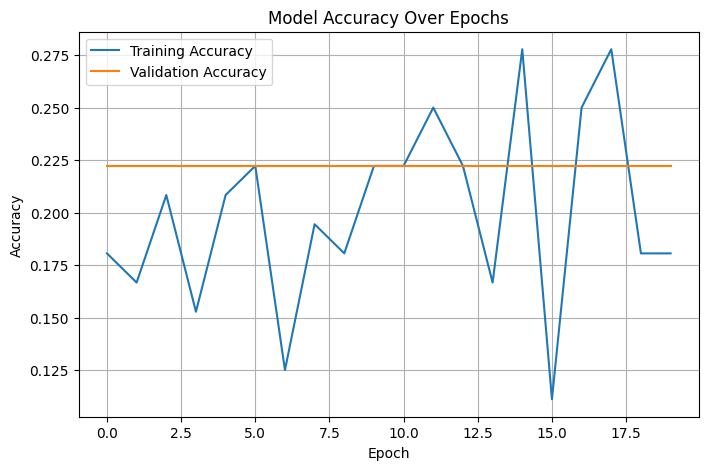

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

***Plot loss graph***

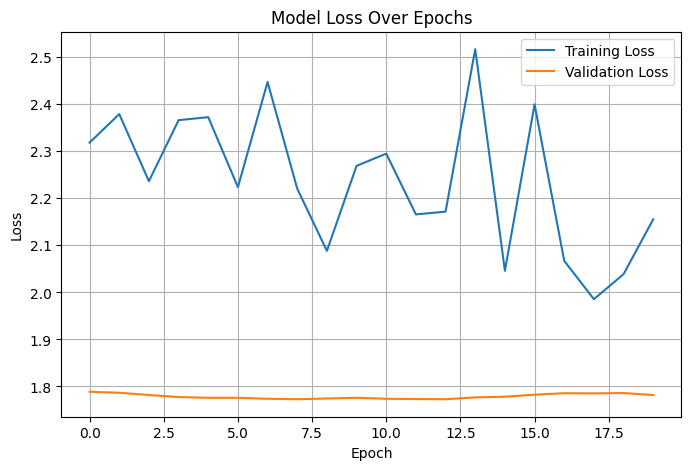

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

***Evaluate CNN model***

In [38]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1667 - loss: 1.8014
Test Loss: 1.8014
Test Accuracy: 0.1667


***Generate inference output***

In [39]:
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:")
print(predicted_labels[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
Predicted labels:
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]


***Classification report for CNN***

In [40]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(classification_report(y_true, predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.17      1.00      0.29         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


***Transfer Learning with VGG16***

***Create VGG16 datasets***

In [41]:
vgg_image_size = (224, 224)
batch_size = 32

train_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=vgg_image_size,
    batch_size=batch_size,
    color_mode="rgb"
)

val_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=vgg_image_size,
    batch_size=batch_size,
    color_mode="rgb"
)

test_vgg = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=vgg_image_size,
    batch_size=batch_size,
    shuffle=False,
    color_mode="rgb"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


***Load pretrained VGG16***

In [42]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


***Freeze the layers***

In [43]:
for layer in base_model.layers:
    layer.trainable = False

***Add custom layers***

In [44]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

***Create final VGG16 model***

In [45]:
model_vgg = Model(inputs=base_model.input, outputs=x)

***Compile VGG16 model***

In [46]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

***Train VGG16 model***

In [49]:
train_vgg = keras.utils.image_dataset_from_directory(
    "/content/dataset/FruitinAmazon/train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    color_mode="rgb"
)

val_vgg = keras.utils.image_dataset_from_directory(
    "/content/dataset/FruitinAmazon/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    color_mode="rgb"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [50]:
history_vgg = model_vgg.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.9028 - loss: 1.7793 - val_accuracy: 0.8889 - val_loss: 2.0348
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 22s/step - accuracy: 0.9306 - loss: 0.6718 - val_accuracy: 0.8889 - val_loss: 1.5383
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.9583 - loss: 0.2305 - val_accuracy: 0.8333 - val_loss: 1.7322
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.9444 - loss: 0.1560 - val_accuracy: 0.7778 - val_loss: 2.0196
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.9583 - loss: 0.0646 - val_accuracy: 0.8333 - val_loss: 2.0924
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 17s/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.8333 - val_loss: 2.1422
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.8333 - val_loss: 2.2170
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 22s/step - accuracy: 0.9861 - loss: 0.0195 - val_accuracy: 0.8333 - val_loss: 2.2837


***Evaluate VGG16***

In [51]:
vgg_loss, vgg_acc = model_vgg.evaluate(test_vgg)
print(f"VGG16 Test Loss: {vgg_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.7333 - loss: 1.9809
VGG16 Test Loss: 1.9809
VGG16 Test Accuracy: 0.7333


***Generate inference output for VGG16***

In [52]:
vgg_predictions = model_vgg.predict(test_vgg)
vgg_predicted_labels = np.argmax(vgg_predictions, axis=1)

print("Predicted labels from VGG16:")
print(vgg_predicted_labels[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
Predicted labels from VGG16:
[0 0 4 4 0 1 5 1 1 5 2 4 2 2 0 3 3 3 3 3]


***Classification report for VGG16***

In [53]:
y_true_vgg = np.concatenate([y for x, y in test_vgg], axis=0)

print(classification_report(y_true_vgg, vgg_predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       1.00      0.60      0.75         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.50      0.60      0.55         5
      tucuma       0.56      1.00      0.71         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.74        30
weighted avg       0.80      0.73      0.74        30



***Compare performance***

In [54]:
print("CNN Test Accuracy:", test_acc)
print("Vgg16 Test Accuracy:", vgg_acc)

CNN Test Accuracy: 0.1666666716337204
Vgg16 Test Accuracy: 0.7333333492279053
